# Eukaryotic functional annotation analysis

Functional descriptions are compared to the mitochondrial-free NCBI RefSeq reference by exact `RNA_ID`; lowercase `protein_id` is retained as sequence provenance. Missing, empty, `-`, and vague descriptions are non-informative. `Both Informative` does not assert biological equivalence.

The first-reference-transcript analysis is deterministic but explicitly noncanonical. Canonical proteins are assigned only in the final section from reviewed Swiss-Prot records, requiring an exact versioned RefSeq `protein_id` cross-reference and exact NCBI FAA amino-acid sequence. Tools do not assign canonical status; they can only recover the externally selected canonical `RNA_ID`.

In [1]:
from pathlib import Path

import pandas as pd

from benchannot.eukaryotic.canonical_mapping import (
    build_canonical_functional_table,
    build_coverage_table,
    ensure_uniprot_cache,
    load_uniprot_cache,
    plot_canonical_coverage,
    read_fasta_ids,
    read_reference_faa,
    resolve_canonical_loci,
)
from benchannot.eukaryotic.functional_analysis import (
    add_reference_baseline,
    categorize_functional_shifts,
    plot_functional_shifts,
    prepare_reference_descriptions,
    select_first_reference_transcript,
)

In [2]:
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / 'pyproject.toml').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate the BenchAnnot project root')

EUKARYOTIC_OUTPUT = PROJECT_ROOT / '2_run' / 'output' / 'eukaryotic'
ANALYSIS_DIR = EUKARYOTIC_OUTPUT / 'functional_analysis'
TABLE_DIR = ANALYSIS_DIR / 'tables'
PLOT_DIR = ANALYSIS_DIR / 'plots'
CACHE_DIR = ANALYSIS_DIR / 'uniprot_cache'
for directory in (TABLE_DIR, PLOT_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TOOLS = ['Kofam', 'Pannzer', 'EggNOG', 'InterProScan']
ORGANISMS = [
    {
        'organism': 'saccharomyces_cerevisiae',
        'display_name': 'Saccharomyces cerevisiae',
        'plot_name': r'$\mathit{S.\ cerevisiae}$',
        'proteome_id': 'UP000002311',
    },
    {
        'organism': 'drosophila_melanogaster',
        'display_name': 'Drosophila melanogaster',
        'plot_name': r'$\mathit{D.\ melanogaster}$',
        'proteome_id': 'UP000000803',
    },
]
for config in ORGANISMS:
    organism = config['organism']
    config['functional_table'] = (
        EUKARYOTIC_OUTPUT / 'tool_preparation' / 'tables'
        / f'{organism}_functional_annotations.tsv'
    )
    config['reference_faa'] = PROJECT_ROOT / 'data' / 'genome_eukaryote' / f'{organism}.faa'
    config['submitted_faa'] = (
        PROJECT_ROOT / 'data' / 'origin' / 'eukaryote_output_tools' / 'gffread'
        / f'{organism}_gffread.faa'
    )
    config['cache'] = CACHE_DIR / f"{organism}_{config['proteome_id']}.json"

In [3]:
functional_tables = {}
required_columns = {
    'RNA_ID', 'protein_id', 'locus_tag', 'Reference', *TOOLS,
    *(f'{tool}_returned' for tool in TOOLS),
}
for config in ORGANISMS:
    table = pd.read_csv(config['functional_table'], sep='\t')
    missing = required_columns - set(table.columns)
    if missing:
        raise ValueError(f"{config['functional_table']} is missing {sorted(missing)}")
    functional_tables[config['organism']] = prepare_reference_descriptions(table)
    table = functional_tables[config['organism']]
    print(f"{config['display_name']}: {len(table):,} RNA_ID, {table['locus_tag'].nunique():,} loci")
    print(table[TOOLS].notna().sum().rename('non-null descriptions').to_string())

Saccharomyces cerevisiae: 6,002 RNA_ID, 6,002 loci
Kofam           3629
Pannzer         5358
EggNOG          5495
InterProScan    4791
Drosophila melanogaster: 30,789 RNA_ID, 13,973 loci
Kofam           16563
Pannzer         26382
EggNOG          28408
InterProScan    25147


## Locus-level first-reference-transcript sensitivity analysis

For both species, this section keeps the first transcript in NCBI RefSeq table order at each locus. The same exact `RNA_ID` is compared across sources. This deterministic reduction is explicitly **noncanonical**.


Saccharomyces cerevisiae first-reference transcript (noncanonical)
                       Both Informative  Both Hypothetical  Over-Annotation  Under-Annotation
NCBI RefSeq reference              5209                793                0                 0
EggNOG                             5017                355              438               192
InterProScan                       3570                536              257              1639
Kofam                              3458                638              155              1751
Pannzer                            4930                459              334               279


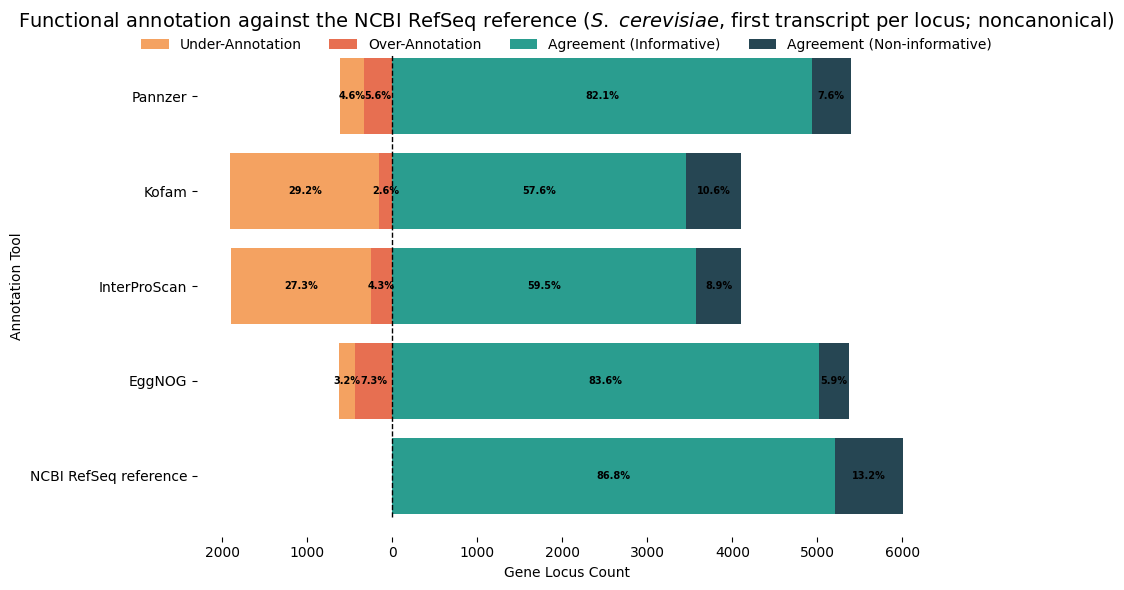


Drosophila melanogaster first-reference transcript (noncanonical)
                       Both Informative  Both Hypothetical  Over-Annotation  Under-Annotation
NCBI RefSeq reference              7848               6125                0                 0
EggNOG                             7010               2516             3609               838
InterProScan                       5442               3525             2600              2406
Kofam                              5165               4426             1699              2683
Pannzer                            6900               1887             4238               948


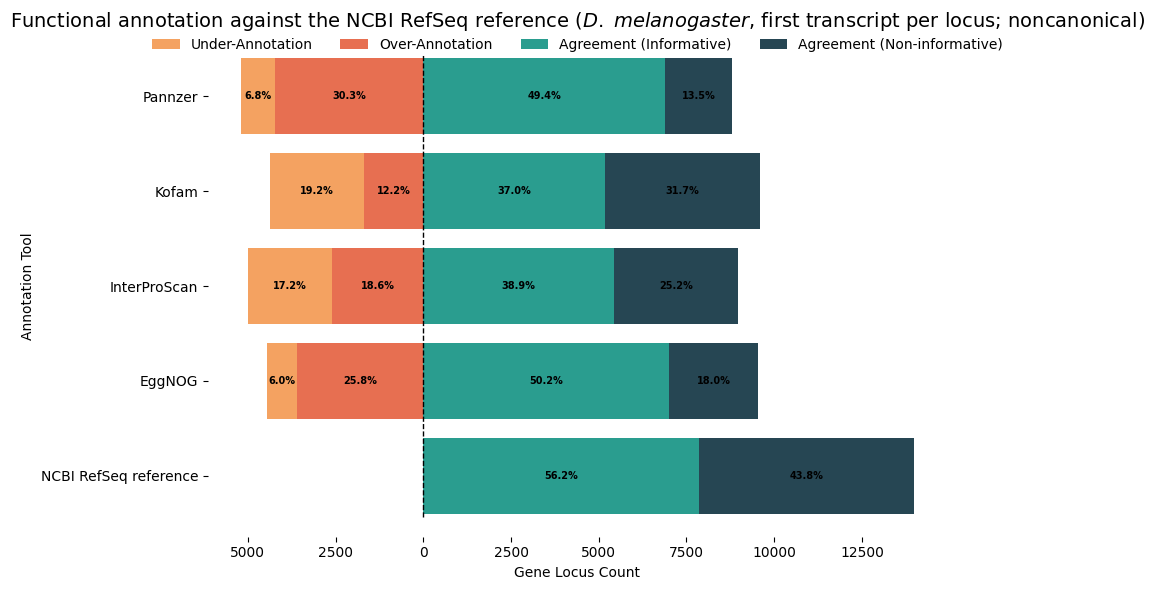

In [4]:
for config in ORGANISMS:
    organism = config['organism']
    first = select_first_reference_transcript(functional_tables[organism])
    summary, details = categorize_functional_shifts(first, TOOLS)
    plot_input = add_reference_baseline(summary, first)
    first.to_csv(TABLE_DIR / f'{organism}_first_reference_transcript_input.tsv', sep='\t', index=False)
    plot_input.rename_axis('Source').reset_index().to_csv(
        TABLE_DIR / f'{organism}_first_reference_transcript_summary.tsv', sep='\t', index=False
    )
    details.to_csv(
        TABLE_DIR / f'{organism}_first_reference_transcript_details.tsv', sep='\t', index=False
    )
    print(f"\n{config['display_name']} first-reference transcript (noncanonical)")
    print(plot_input.to_string())
    plot_functional_shifts(
        plot_input,
        f"Functional annotation against the NCBI RefSeq reference ({config['plot_name']}, first transcript per locus; noncanonical)",
        PLOT_DIR / f'{organism}_first_reference_transcript_functional.png',
        count_label='Gene Locus',
    )

## All-RNA_ID analysis

Every NCBI RefSeq `RNA_ID` is evaluated independently. The yeast universe is intentionally not deduplicated if exact RNA records encode duplicate proteins.


Saccharomyces cerevisiae all RNA_ID
                       Both Informative  Both Hypothetical  Over-Annotation  Under-Annotation
NCBI RefSeq reference              5209                793                0                 0
EggNOG                             5017                355              438               192
InterProScan                       3570                536              257              1639
Kofam                              3458                638              155              1751
Pannzer                            4930                459              334               279


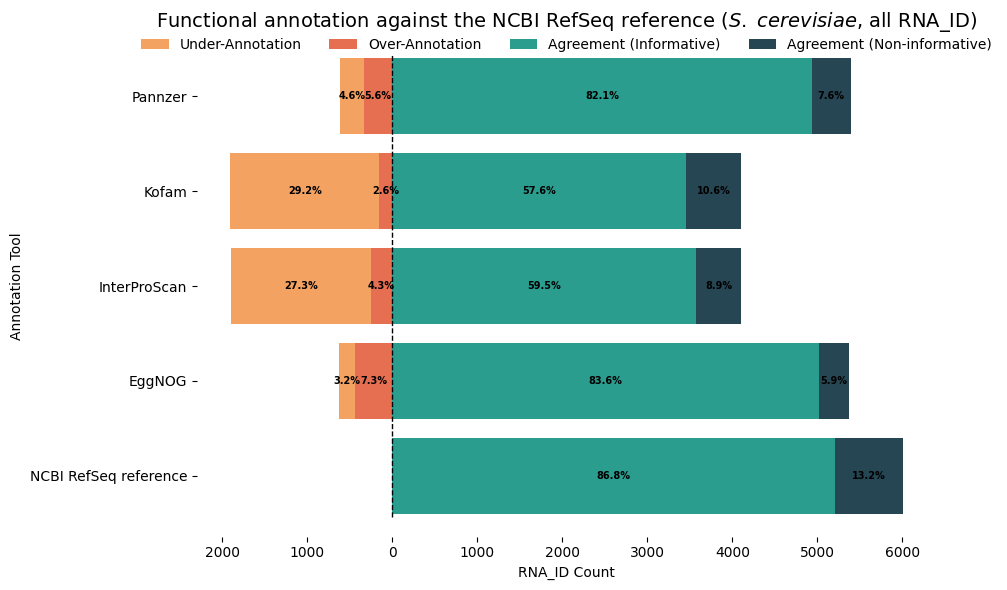


Drosophila melanogaster all RNA_ID
                       Both Informative  Both Hypothetical  Over-Annotation  Under-Annotation
NCBI RefSeq reference             20085              10704                0                 0
EggNOG                            18283               4008             6696              1802
InterProScan                      13841               5877             4827              6244
Kofam                             13241               7428             3276              6844
Pannzer                           18019               2992             7712              2066


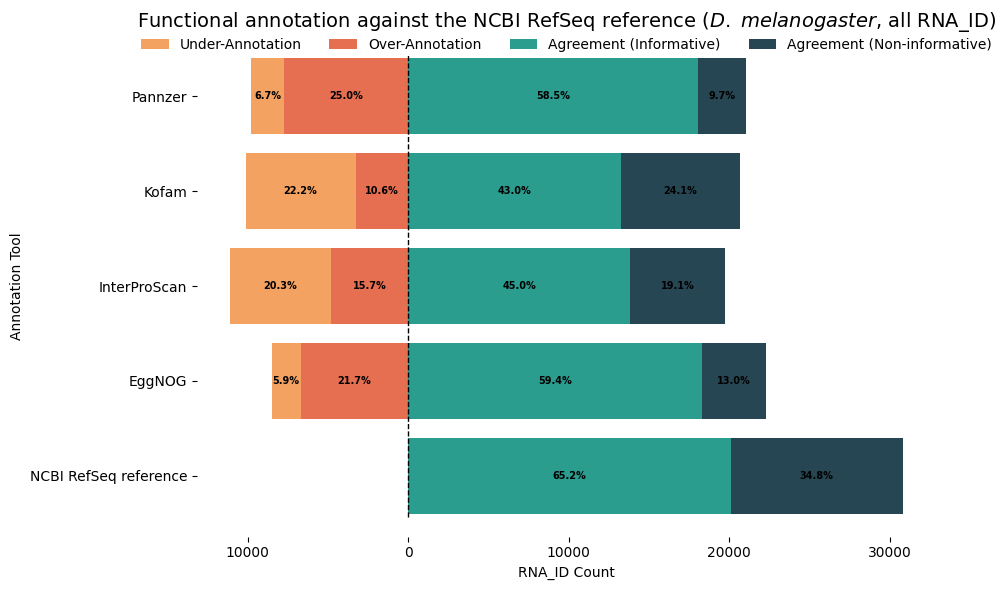

In [5]:
for config in ORGANISMS:
    organism = config['organism']
    table = functional_tables[organism]
    summary, details = categorize_functional_shifts(table, TOOLS)
    plot_input = add_reference_baseline(summary, table)
    table.to_csv(TABLE_DIR / f'{organism}_all_RNA_ID_input.tsv', sep='\t', index=False)
    plot_input.rename_axis('Source').reset_index().to_csv(
        TABLE_DIR / f'{organism}_all_RNA_ID_summary.tsv', sep='\t', index=False
    )
    details.to_csv(TABLE_DIR / f'{organism}_all_RNA_ID_details.tsv', sep='\t', index=False)
    print(f"\n{config['display_name']} all RNA_ID")
    print(plot_input.to_string())
    plot_functional_shifts(
        plot_input,
        f"Functional annotation against the NCBI RefSeq reference ({config['plot_name']}, all RNA_ID)",
        PLOT_DIR / f'{organism}_all_RNA_ID_functional.png',
        count_label='RNA_ID',
    )

## Reviewed Swiss-Prot canonical analysis

Only uniquely resolved canonical protein sequences enter the functional denominator. Equivalent exact transcripts retain a tie status and use NCBI RefSeq order for plotting. Ambiguity, conflicts, and absent reviewed mappings never trigger fallback. A canonical RNA absent from submitted input remains in the denominator with missing tool annotations.


Saccharomyces cerevisiae Swiss-Prot canonical statuses
resolution_status
resolved_canonical     5823
no_reviewed_mapping     156
sequence_conflict        23

Submission status among uniquely resolved canonical loci
submission_status
submitted    5823

Coverage plotted
               Source  RNA_ID count  Represented loci  Recovered canonical RNA_ID
NCBI RefSeq reference          6002              6002                        5823
                Kofam          3629              3629                        3584
              Pannzer          5358              5358                        5252
               EggNOG          5495              5495                        5355
         InterProScan          4791              4791                        4683

Canonical functional plot input
                       Both Informative  Both Hypothetical  Over-Annotation  Under-Annotation
NCBI RefSeq reference              5053                770                0                 0
EggNOG           

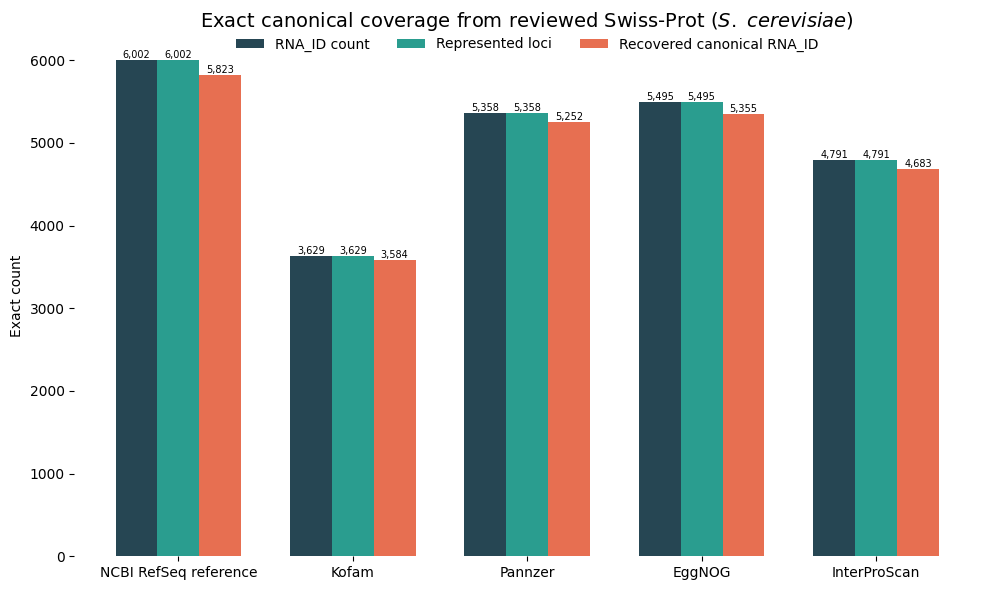

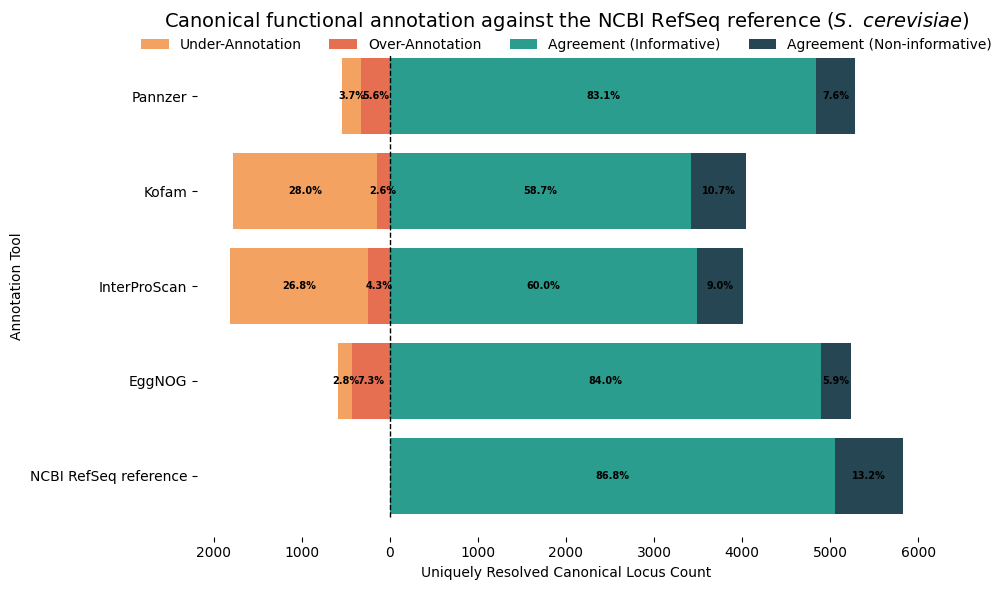


Drosophila melanogaster Swiss-Prot canonical statuses
resolution_status
no_reviewed_mapping            10053
resolved_canonical              2386
equivalent_transcript_tie       1461
sequence_conflict                 52
ambiguous_reviewed_isoforms       21

Submission status among uniquely resolved canonical loci
submission_status
submitted                  3818
canonical_not_submitted      29

Coverage plotted
               Source  RNA_ID count  Represented loci  Recovered canonical RNA_ID
NCBI RefSeq reference         30789             13973                        3847
                Kofam         16563              7134                        2951
              Pannzer         26382             11715                        3536
               EggNOG         28408             12653                        3736
         InterProScan         25147             10990                        3538

Canonical functional plot input
                       Both Informative  Both Hypothetical 

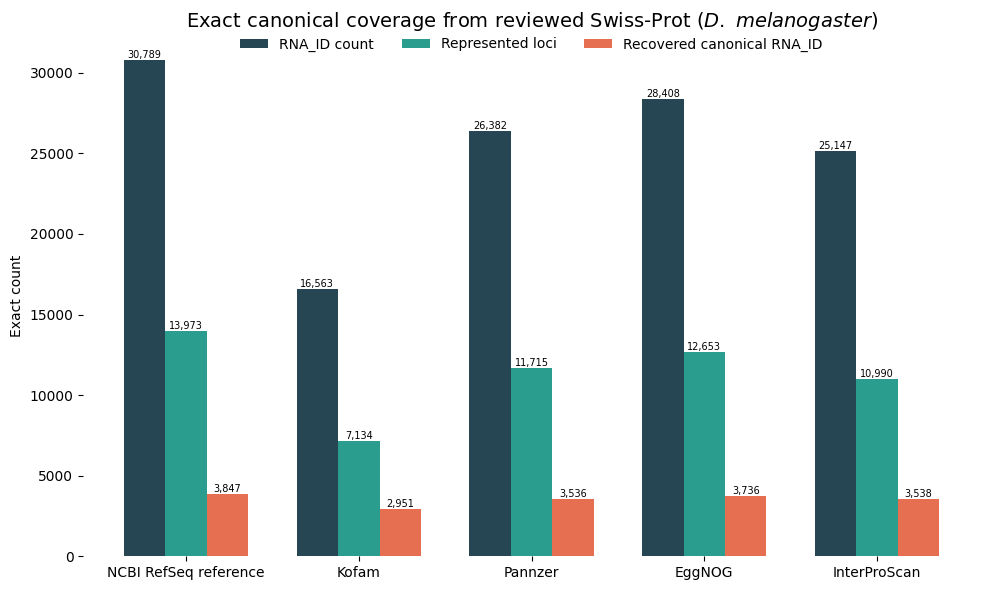

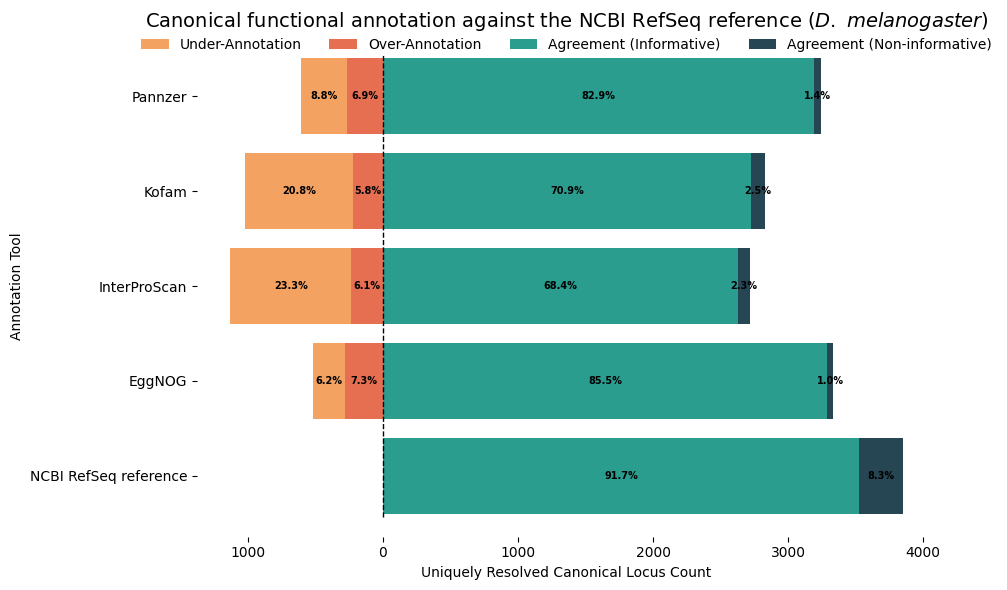

In [6]:
for config in ORGANISMS:
    organism = config['organism']
    cache_path = ensure_uniprot_cache(config['proteome_id'], config['cache'])
    cache_payload = load_uniprot_cache(cache_path, config['proteome_id'])
    faa_sequences = read_reference_faa(config['reference_faa'])
    submitted_ids = read_fasta_ids(config['submitted_faa'])
    table = functional_tables[organism]
    mapping, selection = resolve_canonical_loci(
        table, faa_sequences, cache_payload, submitted_rna_ids=submitted_ids
    )
    canonical = build_canonical_functional_table(table, selection)
    coverage = build_coverage_table(table, selection, TOOLS)
    summary, details = categorize_functional_shifts(canonical, TOOLS)
    plot_input = add_reference_baseline(summary, canonical)

    mapping.to_csv(TABLE_DIR / f'{organism}_canonical_mapping.tsv', sep='\t', index=False)
    selection.to_csv(TABLE_DIR / f'{organism}_canonical_selection.tsv', sep='\t', index=False)
    coverage.to_csv(TABLE_DIR / f'{organism}_canonical_coverage.tsv', sep='\t', index=False)
    canonical.to_csv(TABLE_DIR / f'{organism}_canonical_functional_input.tsv', sep='\t', index=False)
    plot_input.rename_axis('Source').reset_index().to_csv(
        TABLE_DIR / f'{organism}_canonical_functional_summary.tsv', sep='\t', index=False
    )
    details.to_csv(
        TABLE_DIR / f'{organism}_canonical_functional_details.tsv', sep='\t', index=False
    )

    print(f"\n{config['display_name']} Swiss-Prot canonical statuses")
    print(mapping.drop_duplicates('locus_tag')['resolution_status'].value_counts().to_string())
    print('\nSubmission status among uniquely resolved canonical loci')
    print(selection['submission_status'].value_counts().to_string())
    print('\nCoverage plotted')
    print(coverage.to_string(index=False))
    print('\nCanonical functional plot input')
    print(plot_input.to_string())

    plot_canonical_coverage(
        coverage,
        f"Exact canonical coverage from reviewed Swiss-Prot ({config['plot_name']})",
        PLOT_DIR / f'{organism}_canonical_coverage.png',
    )
    plot_functional_shifts(
        plot_input,
        f"Canonical functional annotation against the NCBI RefSeq reference ({config['plot_name']})",
        PLOT_DIR / f'{organism}_canonical_functional.png',
        count_label='Uniquely Resolved Canonical Locus',
    )